# Customer Churn Prediction System


### Business Understanding & Initial Data Exploration

## Objective

The objective of this notebook is to understand the business problem and perform an initial exploration of the dataset.

At this stage, no data preprocessing, feature engineering, or machine learning models will be applied. The focus is on understanding the dataset structure, identifying the target variable, and exploring the available features before moving to the next stages of the project.

In [2]:
import pandas as pd
import numpy as np

print(pd.__version__)
print(np.__version__)

3.0.5
2.5.1


In [3]:
from pathlib import Path
Path.cwd()

WindowsPath('c:/AI-Projects/customer-churn-prediction-system/notebooks')

In [4]:
data_path = Path("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

print(data_path)

data_path.exists()

..\data\WA_Fn-UseC_-Telco-Customer-Churn.csv


True

In [5]:
df = pd.read_csv(data_path)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
df.shape

(7043, 21)

### Dataset Shape

This step checks the size of the dataset.

**Observations:**
- The dataset contains 7043 rows and  21 columns.
- The dataset size is suitable for developing and evaluating a machine learning model during this project.

In [7]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

### Dataset Columns

This step lists all available features.

**Observations:**
- The dataset contains customer demographic, account, and service-related information.
- The target variable is expected to be **Churn**.

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

### Dataset Information

This step inspects the data types and missing values.

**Observations:**
- The dataset contains both numerical and categorical features.
- Some columns require further inspection before preprocessing.

In [9]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


### Numerical Features Summary

This summary provides basic statistics for numerical variables.

**Observations:**
- The numerical features have different value ranges.
- Some features may require scaling later depending on the selected algorithm.

In [10]:
df.describe(include="object")

C:\Users\Mohamed\AppData\Local\Temp\ipykernel_4784\702825166.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,20.2,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


### Categorical Features Summary

This summary helps understand categorical variables.

**Observations:**
- Several categorical variables have only a few unique values.
- These features will require encoding in a later stage.

In [11]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

### Missing Values

This step checks for missing values.

**Observations:**
- No missing values were detected.
- Data completeness is good, although further validation is still required.

In [12]:
df.duplicated().sum()

np.int64(0)

### Duplicate Records

This step checks for duplicated rows.

**Observations:**
- No duplicated records were found.

In [13]:
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

In [14]:
# imports
import matplotlib.pyplot as plt

## 1. Target Variable Analysis

The target variable in this project is `Churn`.

The objective of this analysis is to understand the distribution of
customers who churned versus customers who did not churn.

### Target Distribution

In [15]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [16]:
df["Churn"].value_counts(normalize=True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

In [17]:
churn_distribution = df["Churn"].value_counts(normalize=True) * 100

churn_distribution

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

### Visualization

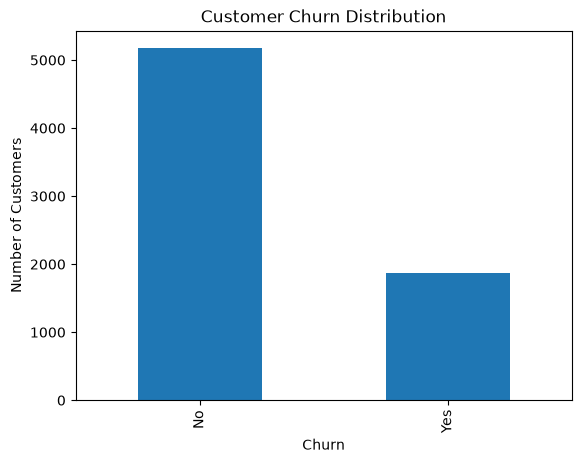

In [18]:
df["Churn"].value_counts().plot(kind="bar")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

### Observation

- The `Churn` target contains two classes: `Yes` and `No`.
- The classes are not equally distributed.
- The majority class is `No`, representing approximately `73%` of the dataset.
- The minority class is `Yes`, representing approximately `27%` of the dataset.

### Initial Insight

The target variable shows class imbalance, which should be considered
when selecting evaluation metrics for the classification model.

## 2. Numerical Features Analysis

The objective of this section is to understand the distribution,
central tendency, spread, and potential anomalies in the numerical
features before performing any preprocessing.

In [19]:
numerical_features = df.select_dtypes(include="number").columns

numerical_features

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges'], dtype='str')

In [20]:
df[numerical_features].describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


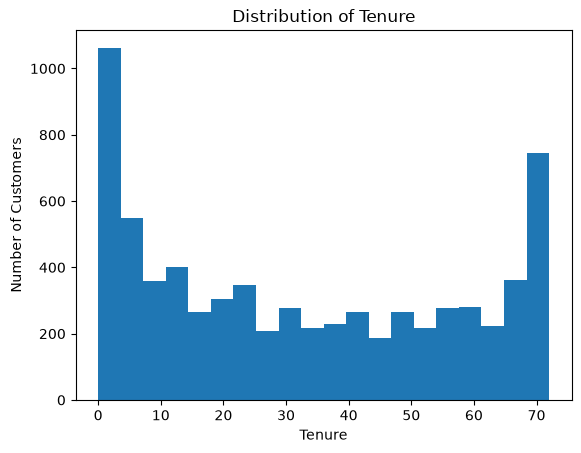

In [21]:
df["tenure"].plot(kind="hist", bins=20)

plt.title("Distribution of Tenure")
plt.xlabel("Tenure")
plt.ylabel("Number of Customers")
plt.show()

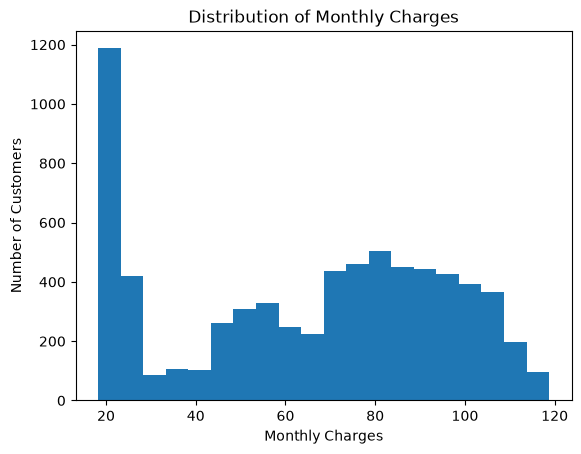

In [22]:
df["MonthlyCharges"].plot(kind="hist", bins=20)

plt.title("Distribution of Monthly Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")
plt.show()

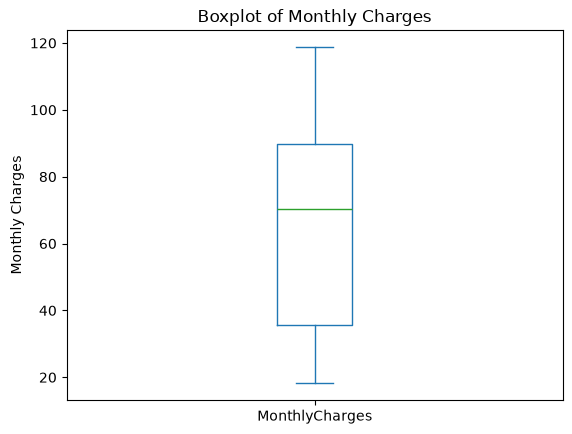

In [23]:
df["MonthlyCharges"].plot(kind="box")

plt.title("Boxplot of Monthly Charges")
plt.ylabel("Monthly Charges")
plt.show()

## Numerical Features Summary

### Key Observations

* The dataset contains several numerical features with different ranges and distributions.
* `tenure` represents the customer's subscription duration and covers a range of customer lifetimes.
* `MonthlyCharges` shows variation in the monthly amount paid by customers.
* The numerical features do not all follow the same distribution, indicating that each feature may require individual consideration during preprocessing.
* Differences between the mean and median suggest that some numerical features may be skewed.

### Potential Issues to Investigate

* Some numerical features show potential outliers based on their boxplots.
* The distributions of some features are not perfectly symmetric.
* The relationship between numerical features and the target variable still needs to be investigated.

### Important EDA Decision

No numerical values were removed, transformed, or scaled during this stage. The purpose of this analysis was to understand the existing data before making preprocessing decisions.


## 3. Categorical Features Analysis

The objective of this section is to understand the categories,
their frequencies, and the overall distribution of categorical
features before analyzing their relationship with the target.

In [24]:
categorical_features = df.select_dtypes(include = 'object').columns
categorical_features

C:\Users\Mohamed\AppData\Local\Temp\ipykernel_4784\1919193104.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = df.select_dtypes(include = 'object').columns


Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges',
       'Churn'],
      dtype='str')

In [25]:
for feature in categorical_features:
    print(f"{feature}: {df[feature].nunique()} unique values")

customerID: 7043 unique values
gender: 2 unique values
Partner: 2 unique values
Dependents: 2 unique values
PhoneService: 2 unique values
MultipleLines: 3 unique values
InternetService: 3 unique values
OnlineSecurity: 3 unique values
OnlineBackup: 3 unique values
DeviceProtection: 3 unique values
TechSupport: 3 unique values
StreamingTV: 3 unique values
StreamingMovies: 3 unique values
Contract: 3 unique values
PaperlessBilling: 2 unique values
PaymentMethod: 4 unique values
TotalCharges: 6531 unique values
Churn: 2 unique values


In [26]:

categores_results = {}

for i in categorical_features:
    counts =  df[i].value_counts()
    percentages = df[i].value_counts(normalize=True) * 100
    
    categores_results [i] = {
        
       " counts":counts,
        "percentages":percentages
        
    } 
    

In [27]:
categores_results["gender"]

{' counts': gender
 Male      3555
 Female    3488
 Name: count, dtype: int64,
 'percentages': gender
 Male      50.47565
 Female    49.52435
 Name: proportion, dtype: float64}

In [28]:
categores_results['Partner']

{' counts': Partner
 No     3641
 Yes    3402
 Name: count, dtype: int64,
 'percentages': Partner
 No     51.69672
 Yes    48.30328
 Name: proportion, dtype: float64}

In [ ]:
import matplotlib.pyplot as plt
import math

n_features = len(categorical_features)
n_cols = 3
n_rows = math.ceil(n_features / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))

axes = axes.flatten()

for index, feature in enumerate(categorical_features):
    df[feature].value_counts().plot(
        kind="bar",
        ax=axes[index]
    )

    axes[index].set_title(f"{feature} Distribution")
    axes[index].set_xlabel(feature)
    axes[index].set_ylabel("Number of Customers")
    axes[index].tick_params(axis="x", rotation=45)

for index in range(n_features, len(axes)):
    axes[index].set_visible(False)

plt.tight_layout()
plt.show()

## Categorical Features Summary

### Key Observations

- The dataset contains multiple categorical features with different numbers of categories.
- The distribution of categories varies across the different categorical features.
- Some features have relatively balanced category distributions, while others are dominated by one category.
- The category counts and percentages were calculated to understand the composition of the customer base.
- Bar charts were used to visually compare the distribution of categories across the categorical features.

### Potential Issues to Investigate

- Some categories have considerably fewer observations than others and may require further investigation during the preprocessing stage.
- Features with highly dominant categories should be considered carefully when preparing the data for modeling.
- Any unusual, missing, or special category values should be investigated before applying encoding or other preprocessing techniques.

### Important Notes

- No categories were removed or modified during this analysis.
- The analysis at this stage focuses only on understanding the distribution of categorical features.
- The relationship between categorical features and the target variable (`Churn`) will be investigated in the next stage.

### Contract vs Churn

Question:

Does the customer's contract type appear to be associated with
customer churn?

In [ ]:
pd.crosstab(df["Contract"], df["Churn"])

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


In [ ]:
contract_churn_rate = pd.crosstab(df["Contract"], df["Churn"], normalize = "index")*100
contract_churn_rate

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


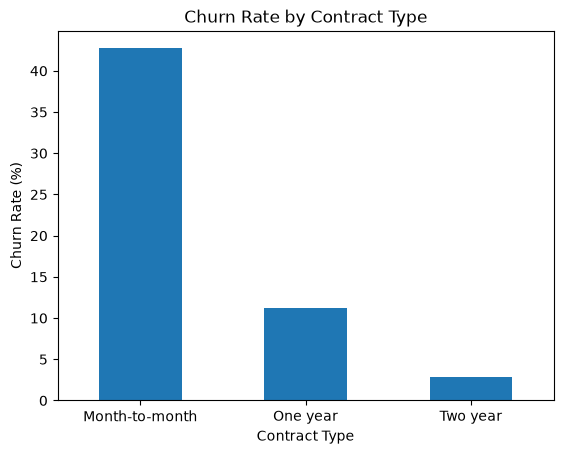

In [ ]:
contract_churn_rate["Yes"].plot(kind="bar")

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

In [ ]:
for feature in categorical_features:
    churn_rate = pd.crosstab(
        df[feature],
        df["Churn"],
        normalize="index"
    ) * 100
    
    print(f"\n{feature}")
    display(churn_rate)


customerID


Churn,No,Yes
customerID,,
0002-ORFBO,100.0,0.0
0003-MKNFE,100.0,0.0
0004-TLHLJ,0.0,100.0
0011-IGKFF,0.0,100.0
0013-EXCHZ,0.0,100.0
...,...,...
9987-LUTYD,100.0,0.0
9992-RRAMN,0.0,100.0
9992-UJOEL,100.0,0.0



gender


Churn,No,Yes
gender,,
Female,73.079128,26.920872
Male,73.839662,26.160338



Partner


...

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700



TotalCharges


Churn,No,Yes
TotalCharges,,
,100.0,0.0
100.2,100.0,0.0
100.25,0.0,100.0
100.35,100.0,0.0
100.4,0.0,100.0
...,...,...
997.75,100.0,0.0
998.1,100.0,0.0
999.45,0.0,100.0



Churn


Churn,No,Yes
Churn,,
No,100.0,0.0
Yes,0.0,100.0


### Tenure vs Churn

Question:

Does customer tenure differ between customers who churned and
customers who did not churn?

In [ ]:
df.groupby("Churn")["tenure"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,37.569965,24.113777,0.0,15.0,38.0,61.0,72.0
Yes,1869.0,17.979133,19.531123,1.0,2.0,10.0,29.0,72.0


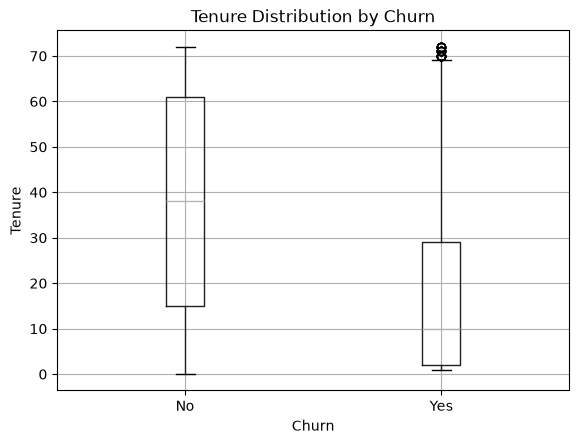

In [ ]:
df.boxplot(column="tenure", by="Churn")

plt.title("Tenure Distribution by Churn")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Tenure")
plt.show()

### MonthlyCharges vs Churn

In [ ]:
df.groupby("Churn")["MonthlyCharges"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,61.265124,31.092648,18.25,25.10,64.425,88.4,118.75
Yes,1869.0,74.441332,24.666053,18.85,56.15,79.650,94.2,118.35


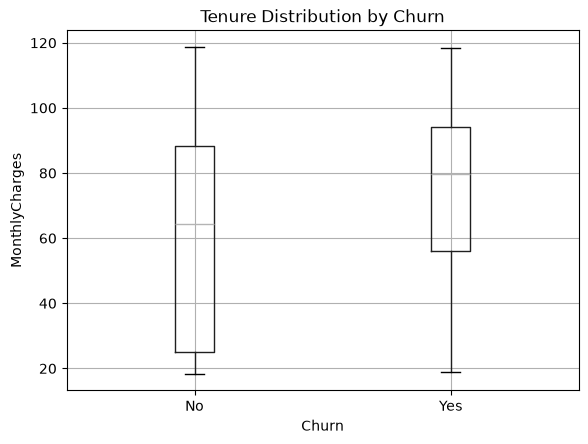

In [ ]:
df.boxplot(column="MonthlyCharges", by="Churn")

plt.title("Tenure Distribution by Churn")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("MonthlyCharges")
plt.show()

### Key Observations

- Contract type shows noticeable differences in observed churn rates across categories.
- Some categorical features show stronger differences in churn rates than others.
- Numerical features such as tenure and MonthlyCharges show differences in their distributions between churn groups.
- These observations indicate that several features may provide useful predictive information.
- Observed associations do not imply causation.

In [ ]:
correlation_matrix = df[numerical_features].corr()

correlation_matrix

,SeniorCitizen,tenure,MonthlyCharges
SeniorCitizen,1.000000,0.016567,0.220173
tenure,0.016567,1.000000,0.247900
MonthlyCharges,0.220173,0.247900,1.000000


In [ ]:
import seaborn as sns

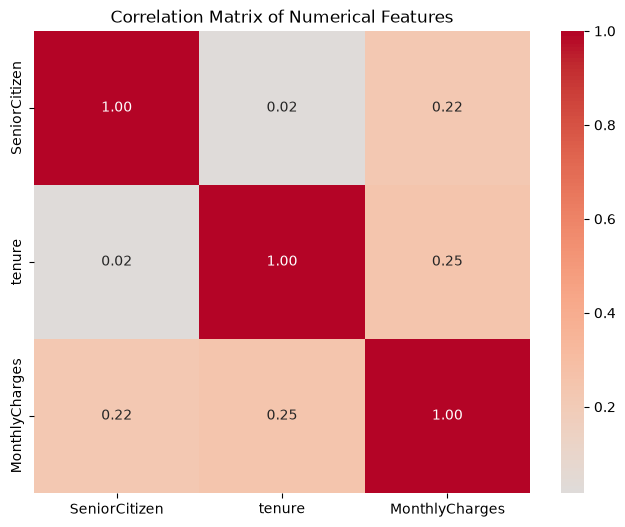

In [ ]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Numerical Features")
plt.show()

### Correlation Summary

- No strong correlations were found among the numerical features.
- `tenure` and `MonthlyCharges` show a weak positive correlation (0.25).
- `SeniorCitizen` has weak correlations with `MonthlyCharges` (0.22) and `tenure` (0.02).
- No significant multicollinearity was observed.

# EDA Summary

## Dataset
- 7,043 customers, 21 columns.
- Target: `Churn` → Binary Classification.

## Key Findings
- Churn rate ≈ 26.5% → target is imbalanced.
- `tenure`, `MonthlyCharges`, and `TotalCharges` show different distributions and require further analysis.
- Several categorical features, especially `Contract`, show clear differences in churn rates.
- `tenure` is noticeably lower among churned customers.
- `tenure` and `TotalCharges` have a strong positive relationship.
- Potential outliers and data-quality issues were identified and will be handled during preprocessing.

## Modeling Implications
- Categorical features require encoding.
- Numerical features may require scaling depending on the model.
- Accuracy alone will not be sufficient for evaluation because of class imbalance.
- Correlated features should be considered during modeling.

## Next Step
- Clean and validate the data.
- Build the preprocessing pipeline.
- Prepare the data for model training.